# §6 Monte Carlo on combined ML#2 (v12 top-50 raw-Sharpe, V3 combo-agnostic filter) — net of costs

IID bootstrap on the ML#2-filtered portfolio trade stream under
`fixed_dollars_500`. Same plot set as §3.

**Cost model:** every trade is charged `contracts × $5.00` round-trip (≈ $3 retail commission + 2 ticks/side slippage on MNQ at $0.50/tick).

In [1]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd

REPO = Path.cwd().resolve()
while not (REPO / 'src').exists() and REPO.parent != REPO:
    REPO = REPO.parent
sys.path.insert(0, str(REPO))

from scripts.evaluation._top_perf_common import (
    STARTING_EQUITY, POLICIES,
    apply_sizing, metrics_from_pnl, monte_carlo,
    load_setup,
    plot_indiv_equity, plot_indiv_dd,
    plot_combined_equity, plot_combined_dd,
    plot_ml2_indiv_equity, plot_ml2_indiv_dd,
    plot_ml2_combined_equity, plot_ml2_combined_dd,
    plot_mc_sims, plot_mc_pnl, plot_mc_sharpe, plot_mc_dd,
)

_ctx = load_setup(cost_per_contract_rt=5.0, top_strategies_path=REPO / 'evaluation' / 'top_strategies_v12_raw_sharpe_top50.json', version='v3_no_gcid')
bars            = _ctx['bars']
YEARS_SPAN      = _ctx['years_span']
strategies      = _ctx['strategies']
results_raw     = _ctx['results_raw']
combined_raw    = _ctx['combined_raw']
combos_ml2      = _ctx['combos_ml2']
s4_pnl_by_combo = _ctx['s4_pnl_by_combo']
ml2_portfolio   = _ctx['ml2_portfolio']


Top-K source: top_strategies_v12_raw_sharpe_top50.json


Test partition: 514,563 bars  2024-10-22 05:08:00 -> 2026-04-08 20:20:00
Years span: 1.461  (used to annualize Sharpe)
Applying friction: $5.00/contract RT (commission + slippage).
Loaded 50 strategies.
Loaded results_raw from cache (50 combos).
Combined unfiltered trades: 43,846
Loaded combos_ml2 from cache (50 combos).


ML2 portfolio trade counts: {'fixed_dollars_500': 3299}


In [2]:
rows = []
for policy in POLICIES:
    df = ml2_portfolio[policy]
    if df.empty:
        rows.append({'policy': policy, 'n_trades': 0}); continue
    pnl_p = df['actual_pnl'].to_numpy(dtype=float)
    risk_p = df['dollar_risk'].to_numpy(dtype=float)
    rows.append({'policy': policy,
                 **monte_carlo(pnl_p, risk_p, policy, YEARS_SPAN)})
mc_ml2 = pd.DataFrame(rows)
mc_ml2

,policy,n_sims,n_trades,win_rate,wr_ci_95,dd_p50_pct,dd_p90_pct,dd_p95_pct,dd_p99_pct,dd_worst_pct,...,dd_p95_dollars,dd_p99_dollars,dd_worst_dollars,var_5pct_trade,cvar_5pct_trade,risk_of_ruin_prob,trades_per_year,sharpe_p50,sharpe_ci_95,sharpe_pos_prob
0,fixed_dollars_500,10000,3299,0.263,"(0.2477, 0.278)",52.34,103.65,123.74,168.05,271.6,...,75436.56,96026.91,137266.19,-511.79,-511.79,0.5362,2258.0,0.3054,"(-1.3688, 1.9286)",0.6417


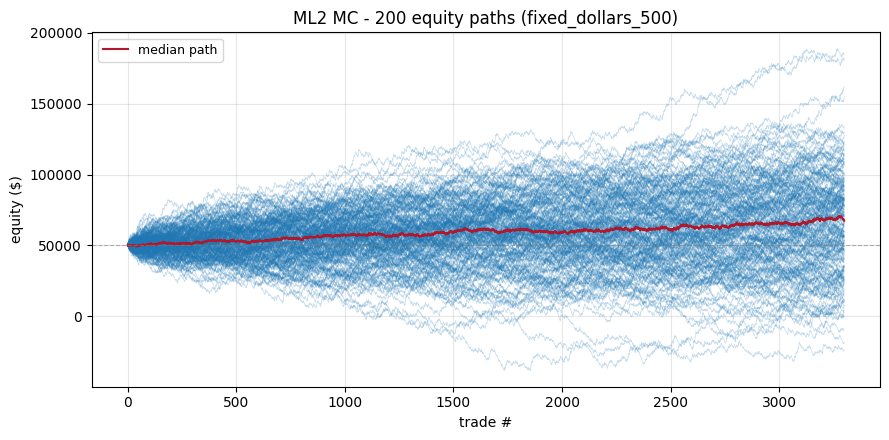

In [3]:
plot_mc_sims(ml2_portfolio['fixed_dollars_500'], 'fixed_dollars_500', 'ML2', YEARS_SPAN)

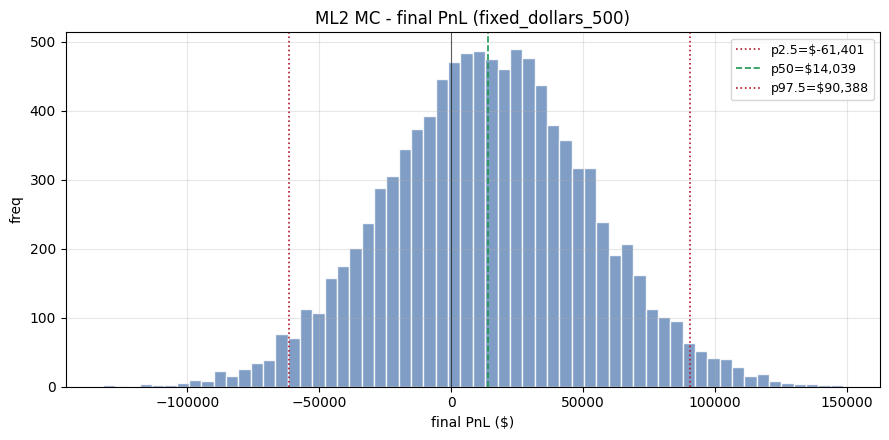

In [4]:
plot_mc_pnl(ml2_portfolio['fixed_dollars_500'], 'fixed_dollars_500', 'ML2', YEARS_SPAN)

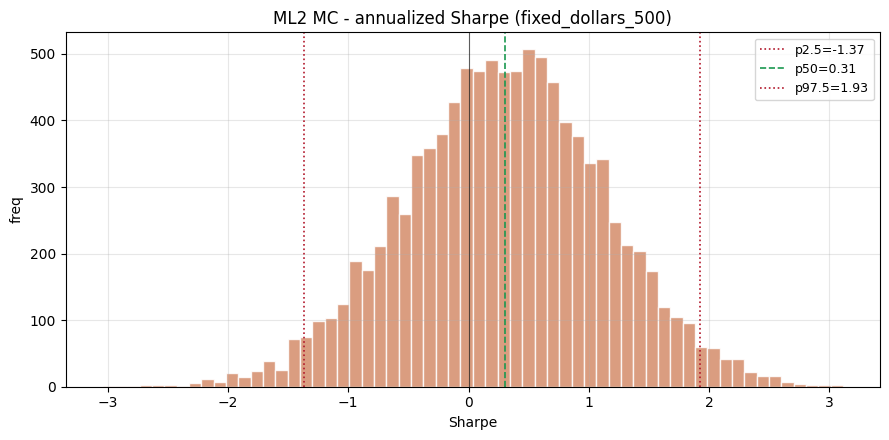

In [5]:
plot_mc_sharpe(ml2_portfolio['fixed_dollars_500'], 'fixed_dollars_500', 'ML2', YEARS_SPAN)

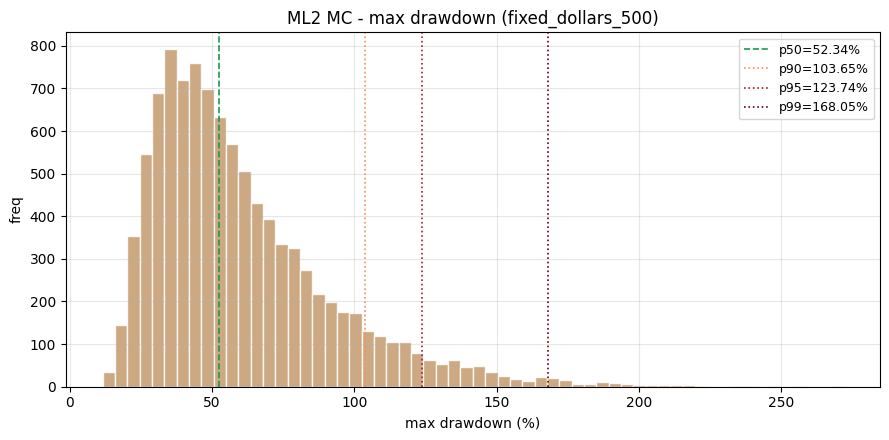

In [6]:
plot_mc_dd(ml2_portfolio['fixed_dollars_500'], 'fixed_dollars_500', 'ML2', YEARS_SPAN)